In [1]:
import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.affinity import scale
from shapely.geometry import MultiPolygon, Point
from shapely.ops import transform
from pyproj import Transformer
import os
import imageio.v3 as iio
import random
from IPython.display import HTML, display

# inspo: https://www.openculture.com/2019/04/animated-maps-animated-maps-reveal-the-true-size-of-countries-the-true-size-of-countries.html#google_vignette

### 1. Compute distortion factors

In [5]:
world = gpd.read_file("zip://ne_10m_admin_0_countries.zip")
world = world[world.ADMIN != 'Antarctica']

# Distorted (Web Mercator)
world = world.to_crs(3857)

# True area (Equal Earth)
moll = "+proj=moll +lon_0=0 +a=6378137 +b=6356752.314245179 +units=m +no_defs"
world_eq = world.to_crs(moll)


# Compute areas
world["area_m2"] = world.geometry.area              # distorted area
world_eq["area_eq_m2"] = world_eq.geometry.area     # true area
world["area_eq_m2"] = world_eq["area_eq_m2"]

In [6]:
world.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
# Compute distortion ratio: distorted / true
world["distortion_ratio"] = world["area_m2"] / world["area_eq_m2"]

world[world["distortion_ratio"]>1].sort_values(by = 'distortion_ratio', ascending = False)[['ADMIN', 'distortion_ratio']]


,ADMIN,distortion_ratio
177,Greenland,16.422224
52,Norway,9.018555
191,Iceland,5.602992
54,Finland,5.459897
155,Canada,5.151608
...,...,...
164,Equatorial Guinea,1.001005
147,Gabon,1.000673
230,Singapore,1.000563
220,São Tomé and Principe,1.000135


<Axes: >

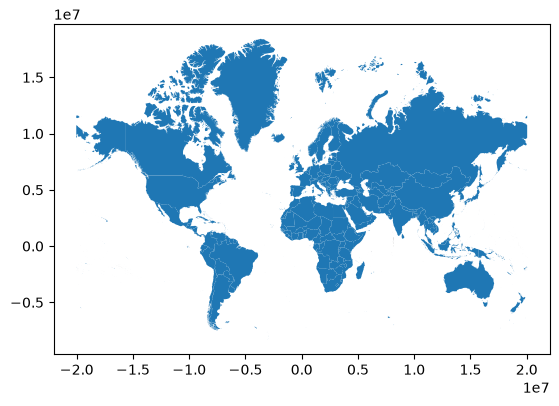

In [8]:
world.plot()

<Axes: >

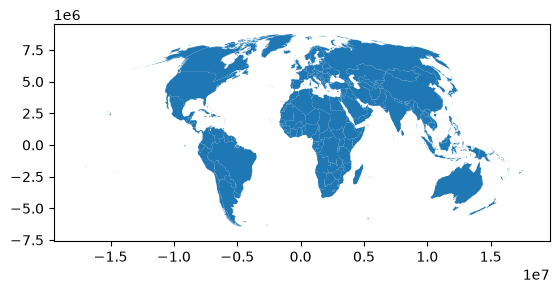

In [9]:
world_eq.plot()

<Axes: >

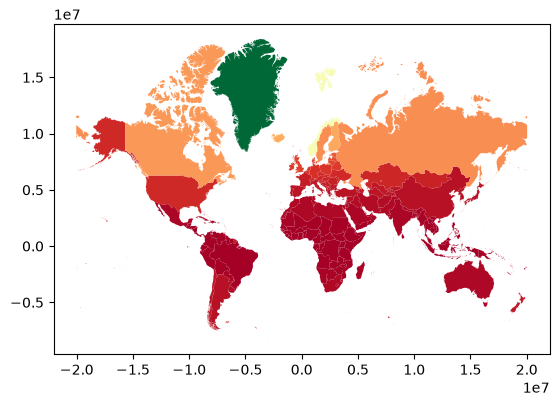

In [12]:
world.plot(column = 'distortion_ratio', cmap = 'RdYlGn')

### 2. Draw the re-scaled map

<Axes: >

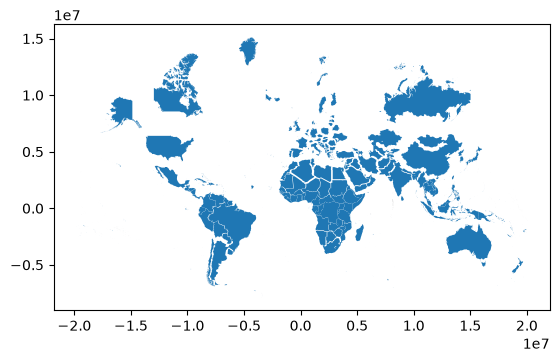

In [13]:
scaled_geoms = []

for idx, row in world.iterrows():

    geom = row.geometry
    ratio = row["distortion_ratio"]

    factor = 1.0 / np.sqrt(row["distortion_ratio"])
    cx, cy = geom.centroid.x, geom.centroid.y


    scaled = scale(
        geom,
        xfact=factor,
        yfact=factor,
        origin=(cx, cy)
    )

    scaled_geoms.append(scaled)


world_scaled = world.copy()
world_scaled["geometry"] = scaled_geoms
world_scaled.plot()

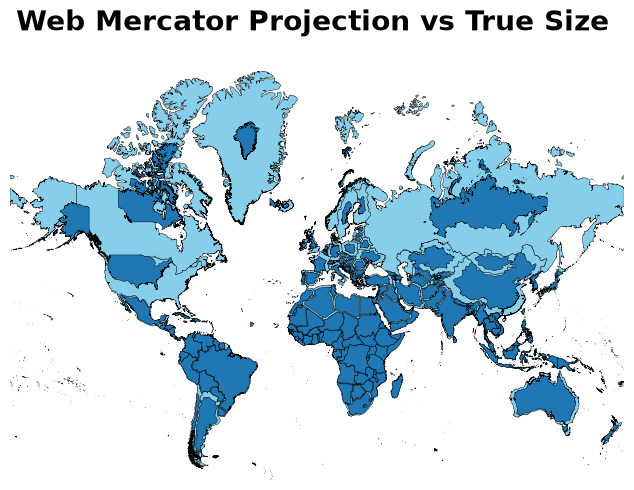

In [14]:
minx, miny, maxx, maxy = world.total_bounds

fig, ax = plt.subplots(1, 1, figsize=(7, 7))

world.plot(ax=ax, edgecolor="k", color = 'skyblue', linewidth=0.3)
world_scaled.plot(ax=ax, edgecolor="black", linewidth=0.3)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.text(0.01, 1.15, "Web Mercator Projection vs True Size", transform=ax.transAxes,
        fontsize=20, fontweight="bold", va="top")


ax.axis('off')
plt.tight_layout()
plt.show()

### 3. Create an animation

In [15]:
world = gpd.read_file("zip://ne_10m_admin_0_countries.zip")
world = world[world.ADMIN != 'Antarctica']

# Distorted (Web Mercator)
world = world.to_crs(3857)
world["area_m2"] = world.area

# Equal-area baseline (Mollweide, spherical Earth)
moll = "+proj=moll +lon_0=0 +R=6371000 +units=m +no_defs"
world_moll = world.to_crs(moll)
world["area_moll_m2"] = world_moll.area

# Area distortion ratio
world["distortion_ratio"] = world["area_m2"] / world["area_moll_m2"]

# Precompute final linear scale factor per country (for t = 1)
world["final_scale"] = 1.0 / np.sqrt(world["distortion_ratio"])

# Global bounds from original world
minx, miny, maxx, maxy = world.total_bounds

In [16]:
n_frames = 30  
foldout = 'frames'
os.makedirs(foldout, exist_ok = True)

In [17]:
for step in range(n_frames + 1):
    t = step / n_frames  # goes 0 → 1

    scaled_geoms = []

    for idx, row in world.iterrows():
        geom = row.geometry
        final_factor = row["final_scale"]

        # interpolate between 1.0 and final_factor
        factor_t = 1.0 + t * (final_factor - 1.0)

        # centroid for anchoring the transformation
        cx, cy = geom.centroid.x, geom.centroid.y

        scaled = scale(
            geom,
            xfact=factor_t,
            yfact=factor_t,
            origin=(cx, cy)
        )
        scaled_geoms.append(scaled)

    # build a temporary GeoDataFrame for this frame
    world_frame = world.copy()
    world_frame["geometry"] = scaled_geoms

    # plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # optional: show original outline faintly for reference
    world.plot(ax=ax, edgecolor="k", facecolor="skyblue", linewidth=0.3)
    world_frame.plot(ax=ax, edgecolor="black", color="steelblue", linewidth=0.3)

    ax.text(0.01, 1.21, "Web Mercator Projection vs True Size", transform=ax.transAxes,
            fontsize=20, fontweight="bold", va="top")


    
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.axis("off")

    plt.tight_layout()
    plt.savefig(foldout + '/' + f"frame_{step:03d}.png", dpi=200)
    plt.close(fig)


In [18]:
files = sorted([f for f in os.listdir(foldout) if f.endswith(".png")])
files

['frame_000.png',
 'frame_001.png',
 'frame_002.png',
 'frame_003.png',
 'frame_004.png',
 'frame_005.png',
 'frame_006.png',
 'frame_007.png',
 'frame_008.png',
 'frame_009.png',
 'frame_010.png',
 'frame_011.png',
 'frame_012.png',
 'frame_013.png',
 'frame_014.png',
 'frame_015.png',
 'frame_016.png',
 'frame_017.png',
 'frame_018.png',
 'frame_019.png',
 'frame_020.png',
 'frame_021.png',
 'frame_022.png',
 'frame_023.png',
 'frame_024.png',
 'frame_025.png',
 'frame_026.png',
 'frame_027.png',
 'frame_028.png',
 'frame_029.png',
 'frame_030.png']

In [19]:
images = [iio.imread(os.path.join(foldout, f)) for f in files]

In [24]:
output_path = "projection_timelaps.mp4"
iio.imwrite(output_path, images, fps=20, codec='libx264', quality=8)

TypeError: TiffWriter.write() got an unexpected keyword argument 'fps'

In [25]:
from IPython.display import display, HTML
display(HTML(f'<video width="500" controls><source src="{output_path}" type="video/mp4"></video>'))

### 4. Design upgrade

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.affinity import scale
import numpy as np
import os
import random

foldout = "frames_neon"
n_frames = 30
n_cycles = 4  
os.makedirs(foldout, exist_ok=True)

# ============================================
# LOAD WORLD + PREPARE PROJECTIONS
# ============================================

world = gpd.read_file("zip://ne_10m_admin_0_countries.zip")
world = world[world.ADMIN != "Antarctica"]

# Web Mercator
world = world.to_crs(3857)
world["area_m2"] = world.area

# Mollweide (equal area)
moll = "+proj=moll +lon_0=0 +R=6371000 +units=m +no_defs"
world_moll = world.to_crs(moll)
world["area_moll_m2"] = world_moll.area

# Distortion ratio and scale factor
world["distortion_ratio"] = world["area_m2"] / world["area_moll_m2"]
world["final_scale"] = 1.0 / np.sqrt(world["distortion_ratio"])

In [18]:
# ============================================
# FIXED NEON COLORS BY CONTINENT
# ============================================

continent_colors = {
    "Africa": "#FF00FF",        # neon magenta
    "Europe": "#00FFFF",        # neon cyan
    "Asia": "#39FF14",          # neon green
    "North America": "#FF073A", # neon red
    "South America": "#FFFF00", # neon yellow
    "Oceania": "#00FF9F",       # neon mint
    "Seven seas (open ocean)": "#00FF9F",       # neon mint
}
world["neon_color"] = world["CONTINENT"].map(continent_colors)


In [19]:
minx, miny, maxx, maxy = world.total_bounds

one_cycle = list(range(n_frames + 1)) + list(range(n_frames - 1, -1, -1))
frame_indices = one_cycle * n_cycles



for frame_id, step in enumerate(frame_indices[0:1]):
    t = step / n_frames  # normalized 0→1→0

    scaled_geoms = []
    for idx, row in world.iterrows():
        geom = row.geometry
        f_final = row["final_scale"]
        f_t = 1.0 + t * (f_final - 1.0)
        cx, cy = geom.centroid.x, geom.centroid.y
        scaled_geoms.append(scale(geom, xfact=f_t, yfact=f_t, origin=(cx, cy)))

    world_frame = world.copy()
    world_frame["geometry"] = scaled_geoms

    fig, ax = plt.subplots(figsize=(10, 10))
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    world_frame.plot(
            ax=ax,
            color=world_frame["neon_color"],
            edgecolor="black",
            linewidth=0.2
        )

    ax.text(
        0.01, 1.05,
        "Web Mercator Projection vs True Size",
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        color="white",
        va="top"
    )

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.axis("off")

    plt.tight_layout()

    plt.savefig(
        f"{foldout}/frame_{frame_id:04d}.png",
        dpi=200,
        facecolor=fig.get_facecolor(),
        bbox_inches="tight"
    )
    plt.close(fig)


In [20]:
files = sorted([f for f in os.listdir(foldout) if f.endswith(".png")])
files

['frame_0000.png',
 'frame_0001.png',
 'frame_0002.png',
 'frame_0003.png',
 'frame_0004.png',
 'frame_0005.png',
 'frame_0006.png',
 'frame_0007.png',
 'frame_0008.png',
 'frame_0009.png',
 'frame_0010.png',
 'frame_0011.png',
 'frame_0012.png',
 'frame_0013.png',
 'frame_0014.png',
 'frame_0015.png',
 'frame_0016.png',
 'frame_0017.png',
 'frame_0018.png',
 'frame_0019.png',
 'frame_0020.png',
 'frame_0021.png',
 'frame_0022.png',
 'frame_0023.png',
 'frame_0024.png',
 'frame_0025.png',
 'frame_0026.png',
 'frame_0027.png',
 'frame_0028.png',
 'frame_0029.png',
 'frame_0030.png',
 'frame_0031.png',
 'frame_0032.png',
 'frame_0033.png',
 'frame_0034.png',
 'frame_0035.png',
 'frame_0036.png',
 'frame_0037.png',
 'frame_0038.png',
 'frame_0039.png',
 'frame_0040.png',
 'frame_0041.png',
 'frame_0042.png',
 'frame_0043.png',
 'frame_0044.png',
 'frame_0045.png',
 'frame_0046.png',
 'frame_0047.png',
 'frame_0048.png',
 'frame_0049.png',
 'frame_0050.png',
 'frame_0051.png',
 'frame_0052

In [21]:
images = [iio.imread(os.path.join(foldout, f)) for f in files]

In [22]:
output_path = "projection_timelaps_neon.mp4"
iio.imwrite(output_path, images, fps=20, codec="libx264", quality=8)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1979, 1397) to (1984, 1408) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [23]:
display(HTML(f'<video width="500" controls><source src="{output_path}" type="video/mp4"></video>'))